### 1. Load the Data
We’ll use sklearn to fetch the data and pandas to handle the calculations.

In [ ]:

from sklearn.datasets import fetch_california_housing
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
print(df)

# We'll focus on 'AveRooms' (Average number of rooms per household)
column = 'AveRooms'

       MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
...       ...       ...       ...        ...         ...       ...       ...   
20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   

       Longitude  
0        -122.23  
1

### 2. Calculate IQR and Define Bounds
We need to find the "fences" that separate normal data from outliers.

In [6]:
# Step 1: Calculate Q1 (25th percentile) and Q3 (75th percentile)
Q1 = df[column].quantile(0.25)
Q3 = df[column].quantile(0.75)

# Step 2: Calculate the Interquartile Range
IQR = Q3 - Q1

# Step 3: Define the Lower and Upper Bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Column: {column}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")

Column: AveRooms
IQR: 1.61
Lower Bound: 2.02 | Upper Bound: 8.47


### 3. Identify and Visualize the Outliers

Before removing them, let's see how many there are and how they look on a plot.

Total Rows: 20640
Outlier Rows: 511


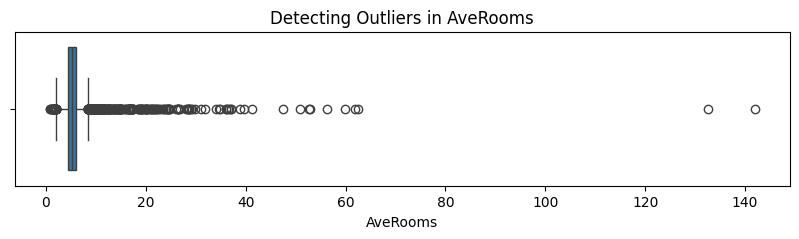

In [ ]:
# Filter the dataframe for outliers
outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

print(f"Total Rows: {len(df)}")
print(f"Outlier Rows: {len(outliers)}")

# Visualize with a boxplot
plt.figure(figsize=(10, 2)) #10 inches wide and 2 inches tall for the canvas. 
sns.boxplot(x=df[column])
plt.title(f'Detecting Outliers in {column}')
plt.show()

## 4. Remove Outliers (Data Cleaning)

If you decide these outliers are skewing your model (e.g., a house with 140 rooms), you can create a "cleaned" version of your dataset.

Shape before: (20640, 8)
Shape after: (20129, 8)


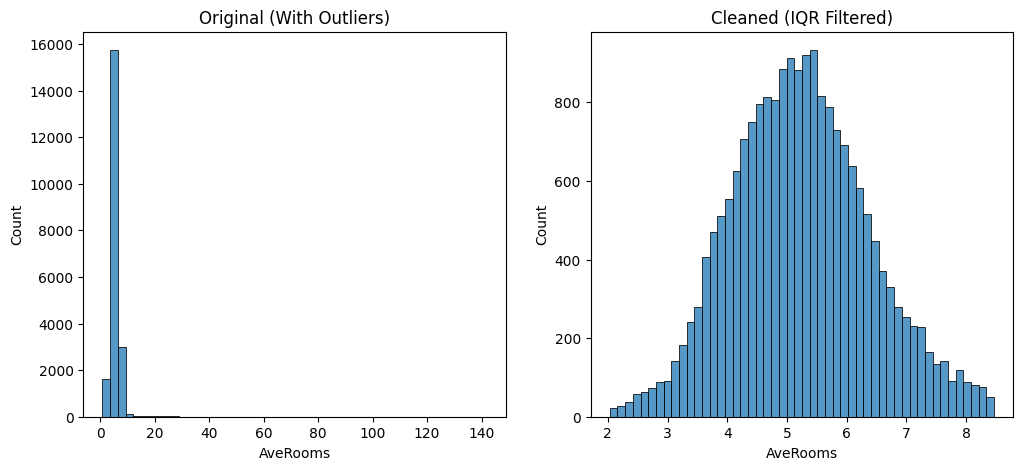

In [ ]:
# Keep only the data within the bounds
df_cleaned = df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

print(f"Shape before: {df.shape}") # (row, cols.)
print(f"Shape after: {df_cleaned.shape}")

# Compare distributions
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# subplotes(1,2) creates grid with 1 row and 2 col.
# figsize=(12, 5) makes the total visible area 12 inches wide by 5 inches tall.
# fig = overall canvas
# ax = array containing two indivdiual plot areas.

sns.histplot(df[column], bins=50, ax=ax[0]).
# bins=50 divides the data into 50 evenly-spaced bars

'''When you have a column of continuous numbers (like 1,000 different ages ranging from 0 to 100), you can't plot a bar for every single unique number—the chart would be a mess.

Instead, bins=50 tells Python:
-> Find the Minimum and Maximum values in that column.
->Divide that total range into 50 equal widths.
->Count how many data points fall into each of those 50 widths.
'''

set_title("Original (With Outliers)")
sns.histplot(df_cleaned[column], bins=50, ax=ax[1]).set_title("Cleaned (IQR Filtered)")
plt.show()